# Unsupervised Learning
Unsupervised Learning Machine Learning ka wo type hai jisme data ke labels (answers) nahi hote. Model khud data me patterns, groups aur relationships dhoondta hai.
## Types of Unsupervised Learning
* 1. Clustering (K_Mean , Hierarchical , DBSCAN)
* 2. Association Rule Learning
* 3. Dimensionality Reduction
* 4. Anomaly Detection (Novelty Detection)

## 1 Clusternig
* Similar data points ko ek group (cluster) me rakhna.
### K_Mean
K-Means Clustering ek Machine Learning algorithm hai jo milti-julti (similar) cheezon ko ek group mein rakh deta hai.
Isay pehle se nahi bataya jata ke kaun kis group mein hai. Ye khud groups banata hai.

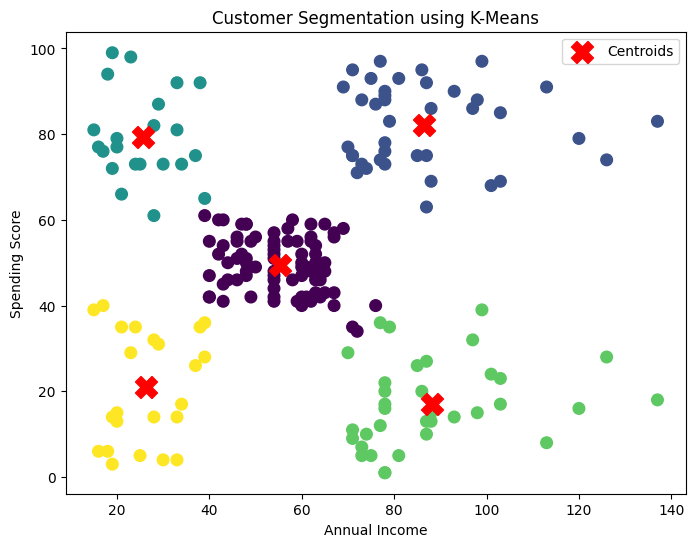

In [ ]:
# K-Mean Clustering

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load Dataset
df = pd.read_csv("Mall_Customers.csv")

# Select Features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Train Model
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X)

# Add Cluster Labels
df['Cluster'] = kmeans.labels_

# Cluster Centers
centers = kmeans.cluster_centers_

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=70
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    color='red',
    marker='X',
    s=250,
    label='Centroids'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.legend()

plt.show()

In [3]:
# New customers: [Annual Income (k$), Spending Score (1-100)]
new_customers = pd.DataFrame({
    'Annual Income (k$)': [25, 60, 90],
    'Spending Score (1-100)': [80, 50, 20]
})

# Predict clusters
predicted_clusters = kmeans.predict(new_customers)

# Display results
new_customers['Predicted Cluster'] = predicted_clusters

print("\nNew Customer Predictions:")
print(new_customers)


New Customer Predictions:
   Annual Income (k$)  Spending Score (1-100)  Predicted Cluster
0                  25                      80                  2
1                  60                      50                  0
2                  90                      20                  3


## Hierarchical Clustering
Similar data ko groups (clusters) mein divide karna.

Lekin ye K-Means se thora different tareeqe se kaam karta hai.

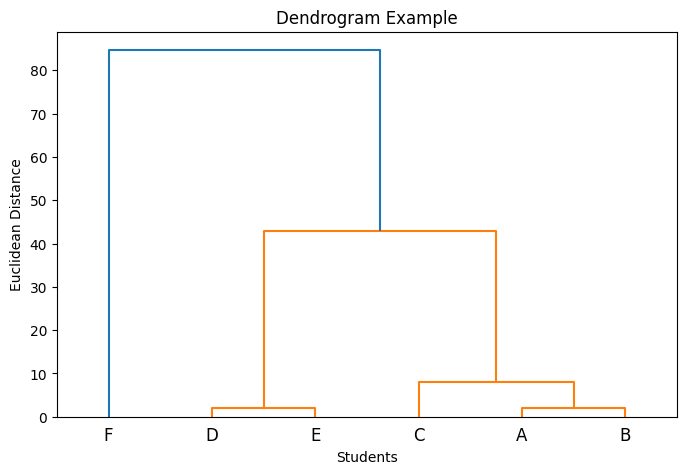

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# -----------------------------
# Create a Simple Dataset
# -----------------------------
df = pd.DataFrame({
    "Student": ["A", "B", "C", "D", "E", "F"],
    "Marks": [10, 12, 18, 40, 42, 90]
})

X = df[["Marks"]]

# -----------------------------
# Create Dendrogram
# -----------------------------
linked = linkage(X, method="ward")

plt.figure(figsize=(8,5))

dendrogram(
    linked,
    labels=df["Student"].values
)

plt.title("Dendrogram Example")
plt.xlabel("Students")
plt.ylabel("Euclidean Distance")

plt.show()

In [5]:
# Train Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=3)

df["Cluster"] = hc.fit_predict(X)

print(df)

  Student  Marks  Cluster
0       A     10        0
1       B     12        0
2       C     18        0
3       D     40        2
4       E     42        2
5       F     90        1


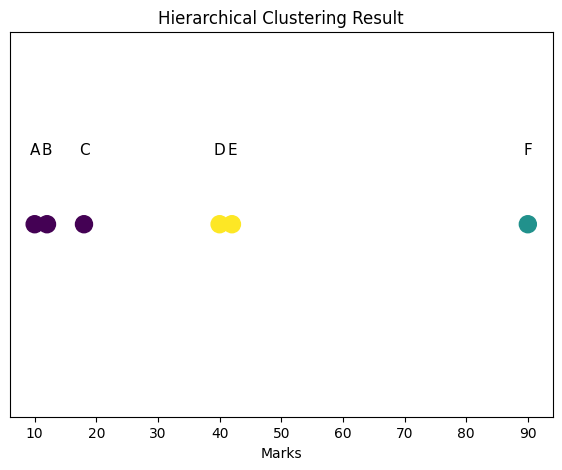

In [ ]:
# Plot the clustering result
plt.figure(figsize=(7,5))

plt.scatter(df["Marks"], [1]*len(df),
            c=df["Cluster"],
            cmap="viridis",
            s=150)

for i, row in df.iterrows():
    plt.text(row["Marks"], 1.02, row["Student"],
             ha="center", fontsize=11)

plt.yticks([])
plt.xlabel("Marks")
plt.title("Hierarchical Clustering Result")

plt.show()

## DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
Jahan data zyada (dense) ho, un points ko ek cluster bana do. Aur jo point akela ho, usay outlier (noise) keh do.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

data = {
    "X": [1,2,2,3,2,8,8,9,9,8,20],
    "Y": [1,1,2,2,3,8,9,8,9,10,20]
}

df = pd.DataFrame(data)

print(df)

     X   Y
0    1   1
1    2   1
2    2   2
3    3   2
4    2   3
5    8   8
6    8   9
7    9   8
8    9   9
9    8  10
10  20  20


In [ ]:
# model Create krna
dbscan = DBSCAN(eps=2, min_samples=3)

# Model Train krna 
df["Cluster"] = dbscan.fit_predict(df)

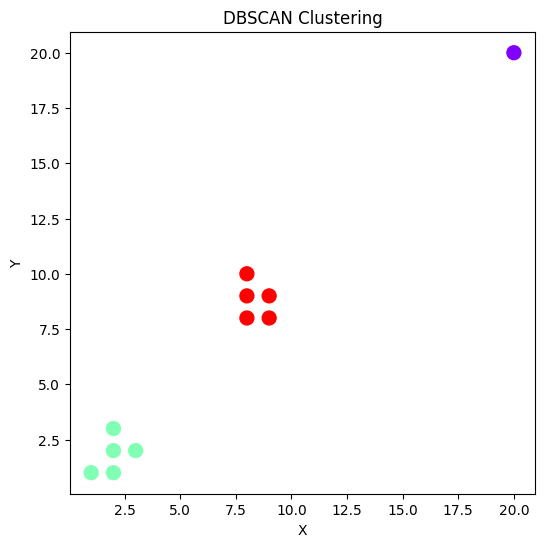

In [13]:
# plot the clustering result
plt.figure(figsize=(6,6))

plt.scatter(
    df["X"],
    df["Y"],
    c=df["Cluster"],
    cmap="rainbow",
    s=100
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("DBSCAN Clustering")

plt.show()

# 2. Association Rule Learning
"Agar ye item purchase hui hai to uske sath konsa item bhi purchase hota hai."
Example

## Supermarket

Agar koi

* Bread
* Butter

leta hai

to wo aksar

* Jam

bhi leta hai.

## Apriori
Apriori ek algorithm hai jo shopping cart analysis (market basket analysis) ke liye use hota hai. Yeh batata hai ke log ek saath konsi cheezein khareedte hain.
## FP-Growth
FP-Growth ek aisa algorithm hai jo fast hai. Yeh bhi Apriori ki tarah shopping patterns find karta hai, lekin zyada tez hai.

### Apriori vs FP-Growth (Simple Difference)
| **Apriori** | **FP-Growth** |
|-------------|---------------|
| Slow hai | Fast hai |
| Baar baar data scan karta hai | Sirf 2 baar scan karta hai |
| Bohot saare combinations banata hai | Combinations nahi banata |
| Tree use nahi karta | FP-Tree use karta hai |


# 3. Dimensionality Reduction
Features ko kam karna bina important information lose kiye.

Suppose

* 100 columns hain.

* Model slow chal raha hai.

* Dimensionality Reduction un 100 ko 10 me convert kar deta hai.

### Example

Face Recognition

1000 pixel values

↓

50 important features

↓

Fast prediction

### PCA (Principal Component Analysis)
PCA (Principal Component Analysis) ek aisa technique hai jo bohot saare features (columns) ko kam features mein convert kar deta hai, lekin important information nahi khota.

### Example: Mobile Phone
Mobile Phone = 100 features

    ↓

PCA (Compress)

    ↓
    
Just 10 main features:
- Screen size
- Camera
- Battery
- Processor
- Storage
...

| Category                 | Models                                                                                                   |
| ------------------------ | -------------------------------------------------------------------------------------------------------- |
| Clustering               | K-Means, Hierarchical, DBSCAN, Mean Shift, GMM, OPTICS, Birch, Spectral Clustering, Affinity Propagation |
| Association Rules        | Apriori, FP-Growth, ECLAT                                                                                |
| Dimensionality Reduction | PCA, Kernel PCA, t-SNE, UMAP, ICA, Truncated SVD, NMF, Autoencoder                                       |
| Anomaly Detection        | Isolation Forest, One-Class SVM, LOF, Elliptic Envelope, Autoencoder                                     |
